In [127]:
import sys
from pathlib import Path

from OMPython import ModelicaSystem

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import docs.plot_setup as plot_setup
plt = plot_setup.set_professional_style()

In [128]:
pkg_path = Path.cwd() / 'ControlledPendulum/package.mo'
model_name = 'ControlledPendulum.Demo_DrivenWithWall'

model = ModelicaSystem(str(pkg_path), model_name)


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.
[/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/Modelica/ControlledPendulum/PendulumWithWall.mo:8:3-9:42:writable] Warning: Parameter pendulum.with_contact has no value, and is fixed during initialization (fixed=true), using available start value (start=true) as default value.
[/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/Modelica/ControlledPendulum/PendulumWithWall.mo:42:5-42:27:writable] Warning: Conditional component 'wall' is used in a non-connect context.



In [129]:
pid_reset_value = 'true'
model.setParameters(f'useReset={pid_reset_value}')
model.buildModel()
model.getSimulationOptions()

[/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/Modelica/ControlledPendulum/PendulumWithWall.mo:8:3-9:42:writable] Warning: Parameter pendulum.with_contact has no value, and is fixed during initialization (fixed=true), using available start value (start=true) as default value.
[/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/Modelica/ControlledPendulum/PendulumWithWall.mo:42:5-42:27:writable] Warning: Conditional component 'wall' is used in a non-connect context.



{'startTime': '0',
 'stopTime': '10',
 'stepSize': '0.01',
 'tolerance': '1e-06',
 'solver': 'dassl',
 'outputFormat': 'mat'}

In [130]:
startTime = 0.0
stopTime  = 10.0
stepSize  = 0.001
model.setSimulationOptions([f'startTime={startTime}', f'stopTime={stopTime}', f'stepSize={stepSize}'])

In [131]:
parameters = model.getParameters()
parameters['pid.I.use_reset']



'true'

In [132]:
model.simulate()

LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


In [133]:
model.getSolutions()

('$whenCondition1',
 '$whenCondition3',
 'der(drive.I)',
 'der(pendulum.pendulum.omega)',
 'der(pendulum.pendulum.q)',
 'der(pid.D.x)',
 'der(pid.I.y)',
 'drive.E',
 'drive.I',
 'drive.L_M',
 'drive.R_M',
 'drive.U',
 'drive.U_M',
 'drive.U_rated',
 'drive.eta_M',
 'drive.i_M',
 'drive.k_M',
 'drive.k_e',
 'drive.k_n',
 'drive.n_0',
 'drive.omega',
 'drive.omega_m',
 'drive.torque',
 'drive.u_control',
 'pendulum.alpha',
 'pendulum.contact',
 'pendulum.omega',
 'pendulum.pendulum.L',
 'pendulum.pendulum.alpha',
 'pendulum.pendulum.g',
 'pendulum.pendulum.inertia',
 'pendulum.pendulum.m',
 'pendulum.pendulum.omega',
 'pendulum.pendulum.omega0',
 'pendulum.pendulum.q',
 'pendulum.pendulum.q0',
 'pendulum.pendulum.torque',
 'pendulum.q',
 'pendulum.torque',
 'pendulum.wall.J_eq',
 'pendulum.wall.autoDamp',
 'pendulum.wall.autoEps',
 'pendulum.wall.c',
 'pendulum.wall.c_eff',
 'pendulum.wall.contact',
 'pendulum.wall.eps',
 'pendulum.wall.eps_eff',
 'pendulum.wall.k',
 'pendulum.wall.omega

In [134]:
solution_names = ('time', 'pid.I_out', 'reference.q_ref', 'pendulum.q', 'pendulum.contact')
results = {name: model.getSolutions(name).flatten() for name in solution_names}

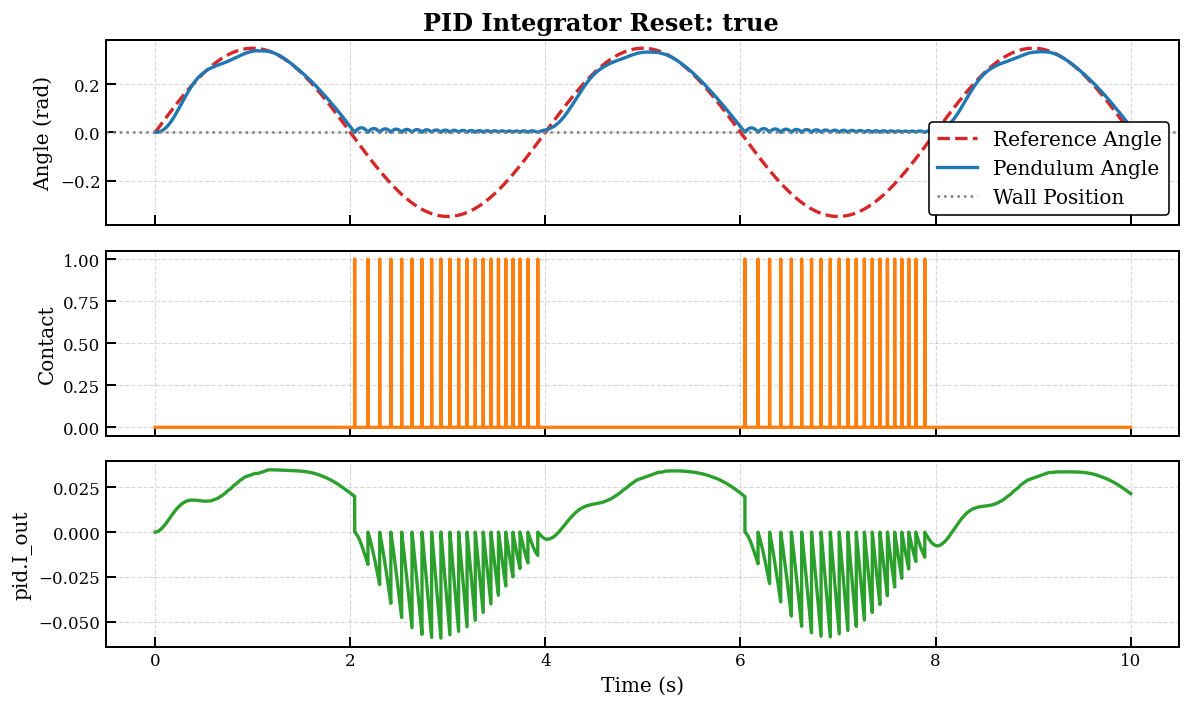

In [135]:
fig, axs = plt.subplots(ncols=1, nrows=3, sharex=True)
fig.set_size_inches(10,6)
fig.suptitle(f'PID Integrator Reset: {pid_reset_value}', fontweight='bold')


# Plot 1: Angles
line1, = axs[0].plot(results['time'], results['reference.q_ref'], 
                     color='tab:red', linewidth=2, label='Reference Angle', linestyle='--')
line2, = axs[0].plot(results['time'], results['pendulum.q'], 
                     color='tab:blue', linewidth=2, label='Pendulum Angle')
line3 = axs[0].axhline(y=0, color='tab:gray', linestyle=':', 
                       linewidth=1.5, label='Wall Position')
axs[0].set_ylabel('Angle (rad)')
axs[0].grid(alpha=0.3, which='both')
axs[0].legend(loc='lower right')

# Plot 2: Contact
line4, = axs[1].plot(results['time'], results['pendulum.contact'], 
                     color='tab:orange', linewidth=2)
axs[1].set_ylabel('Contact')
axs[1].grid(alpha=0.3, which='both')

# Plot 3: PID Integrator
line5, = axs[2].plot(results['time'], results['pid.I_out'], 
                     color='tab:green', linewidth=2)
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('pid.I_out')
axs[2].grid(alpha=0.3, which='both')


plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.savefig(f'modelica_hybrid_reset_{pid_reset_value}.svg')
plt.show()